# 🚂 Railroad Crossing Classification - Claude Only

## 📊 Evaluate 220 Images with Claude 5 Sonnet

This notebook evaluates **220 test images** using:
- ✅ **Claude-sonnet-5** (Anthropic) - State-of-the-art vision model

Images are classified as:
1. Pedestrians
2. VEHICLE
3. TRAIN
4. Empty Crossing

## 🔐 Required API Key

Add to **Colab Secrets** (🔑 icon, left sidebar):

**ANTHROPIC_API_KEY** - From https://console.anthropic.com/

✅ That's it! No other keys needed!

## 📁 Data

- **220 images** in a **flat folder** (no subfolders)
- All formats: .jpg, .jpeg, .png
- Zero-shot classification (no training needed)

⏱️ **Runtime:** ~15 minutes
💰 **Cost:** ~$3-5

---

In [1]:
# ✅ Install dependencies
!pip install -q anthropic

print("✅ Dependencies installed successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.9 MB/s eta 0:00:00
✅ Dependencies installed successfully!


In [2]:
# ✅ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")


Mounted at /content/drive
✅ Google Drive mounted successfully!


In [3]:
# ✅ Load API key from Colab Secrets
from google.colab import userdata
import os

print("Loading API key from Colab Secrets...\n")

try:
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')

    if ANTHROPIC_API_KEY:
        os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
        print("✅ Anthropic API key loaded (Claude)")
    else:
        print("❌ ANTHROPIC_API_KEY not found!")
        print("📝 Please add it to Colab Secrets (🔑 icon)")

except Exception as e:
    print(f"❌ Error: {e}")
    print("📝 Please add ANTHROPIC_API_KEY to Colab Secrets")


Loading API key from Colab Secrets...

✅ Anthropic API key loaded (Claude)


In [4]:
# ✅ Import libraries
import os
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns

# Claude API
try:
    from anthropic import Anthropic
    print("✅ Anthropic imported successfully")
except ImportError:
    print("❌ anthropic package not found - please re-run previous cell")

print("✅ All libraries imported!")


✅ Anthropic imported successfully
✅ All libraries imported!


In [5]:
# ============================================================================
# 📂 DATASET PATH + AUTOMATIC GROUND TRUTH FROM SUBFOLDERS
# ============================================================================

from pathlib import Path
import os
from collections import Counter

folder_path = "/content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Labeled-Data-NN/Journal-version-data/VLM-test-220-multi-class"

# Expected structure:
#
# 220_test/
# ├── Pedestrians/
# ├── VEHICLE/
# ├── TRAIN/
# └── Empty Crossing/

class_prompts_dict = {
    "Pedestrians": "People passing through the railroad crossing",
    "Vehicle": "At least one vehicle is present at the railroad crossing",
    "Train": "A train is on the railway crossing",
    "Empty Crossing": "No object is visible on the railroad",
}

VALID_CLASSES = list(class_prompts_dict.keys())

# Verify main folder
if os.path.exists(folder_path):
    print(f"✅ Dataset folder found: {folder_path}")
else:
    print(f"❌ Dataset folder not found: {folder_path}")

# Verify class folders
for class_name in VALID_CLASSES:
    class_folder = os.path.join(folder_path, class_name)

    if os.path.exists(class_folder):
        print(f"✅ Found class folder: {class_name}")
    else:
        print(f"⚠️ Missing class folder: {class_name}")


✅ Dataset folder found: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Labeled-Data-NN/Journal-version-data/VLM-test-220-multi-class
✅ Found class folder: Pedestrians
✅ Found class folder: Vehicle
✅ Found class folder: Train
✅ Found class folder: Empty Crossing


In [6]:
# ============================================================================
# LOAD IMAGES + CREATE GROUND TRUTH
# ============================================================================

def load_images_with_ground_truth(
    base_folder,
    class_names,
    image_extensions=(".jpg", ".jpeg", ".png")
):
    """
    Load images from class-specific subfolders and automatically
    generate ground-truth labels from folder names.

    Returns:
        image_paths: List of all image paths
        ground_truth_labels: Dict {full_image_path: true_class}
    """

    image_paths = []
    ground_truth_labels = {}

    for class_name in class_names:

        class_folder = Path(base_folder) / class_name

        if not class_folder.exists():
            print(f"⚠️ Class folder not found: {class_folder}")
            continue

        for img_file in class_folder.iterdir():

            if (
                img_file.is_file()
                and img_file.suffix.lower() in image_extensions
            ):

                img_path = str(img_file)

                image_paths.append(img_path)

                # Folder name becomes true class
                ground_truth_labels[img_path] = class_name

    image_paths = sorted(image_paths)

    return image_paths, ground_truth_labels


# Load dataset
image_paths, ground_truth_labels = load_images_with_ground_truth(
    folder_path,
    VALID_CLASSES
)

print("\n" + "=" * 80)
print("📊 DATASET SUMMARY")
print("=" * 80)

print(f"Total images found: {len(image_paths)}")

ground_truth_distribution = Counter(
    ground_truth_labels.values()
)

print("\nGround Truth Distribution:")

for class_name in VALID_CLASSES:
    print(
        f"  • {class_name}: "
        f"{ground_truth_distribution.get(class_name, 0)}"
    )

# Safety check
if len(image_paths) != 220:
    print(
        f"\n⚠️ WARNING: Expected 220 images, "
        f"but found {len(image_paths)}."
    )
else:
    print("\n✅ Exactly 220 images found.")

# Show sample
print("\n📋 Sample images:")

for img_path in image_paths[:5]:
    print(
        f"  {os.path.basename(img_path)} "
        f"→ {ground_truth_labels[img_path]}"
    )



📊 DATASET SUMMARY
Total images found: 220

Ground Truth Distribution:
  • Pedestrians: 36
  • Vehicle: 132
  • Train: 28
  • Empty Crossing: 24

✅ Exactly 220 images found.

📋 Sample images:
  Screenshot 2025-04-05 184045.jpg → Empty Crossing
  Screenshot 2025-04-05 200546.jpg → Empty Crossing
  Screenshot 2025-04-06 212959.jpg → Empty Crossing
  Screenshot 2025-04-07 110840.jpg → Empty Crossing
  Screenshot 2025-04-08 014235.jpg → Empty Crossing


In [7]:
# ✅ Initialize Claude API client
anthropic_client = None
if os.getenv('ANTHROPIC_API_KEY'):
    try:
        anthropic_client = Anthropic()
        print("✅ Claude API initialized (Sonnet-5)")
    except Exception as e:
        print(f"❌ Error initializing Claude: {e}")
else:
    print("❌ ANTHROPIC_API_KEY not found!")
    print("Please ensure API key is in Colab Secrets")


✅ Claude API initialized (Sonnet-5)


In [8]:
def zero_shot_predict_claude(
    image_path,
    class_prompts_dict,
    show_image=False
):
    """
    Performs zero-shot multiclass classification using Claude Sonnet 5.

    """

    if not anthropic_client:
        return None, 0.0, {}, {}

    try:
        # ------------------------------------------------------------
        # 1. Load and encode image
        # ------------------------------------------------------------
        image = Image.open(image_path).convert("RGB")

        buffered = BytesIO()
        image.save(buffered, format="JPEG")

        img_base64 = base64.standard_b64encode(
            buffered.getvalue()
        ).decode("utf-8")

        # ------------------------------------------------------------
        # 2. Build multiclass prompt
        # ------------------------------------------------------------
        class_text = "\n".join(
            [
                f"{label}: {description}"
                for label, description
                in class_prompts_dict.items()
            ]
        )

        prompt_text = f"""
You are a zero-shot image classifier for railroad-crossing scenes.

Classify the provided image into EXACTLY ONE of the following classes:

{class_text}

Instructions:
- Select only one class.
- Use the class descriptions above to determine the best matching class.
- Return ONLY the class label.
- Do not provide explanations.
- Do not return Yes/No.
- Do not return multiple classes.

Valid outputs are exactly:
{", ".join(class_prompts_dict.keys())}

"""

        # ------------------------------------------------------------
        # 3. Call Claude API
        # IMPORTANT: Do NOT pass temperature for Claude Sonnet 5
        # ------------------------------------------------------------
        response = anthropic_client.messages.create(
            model="claude-sonnet-5",
            max_tokens=30,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": img_base64,
                            },
                        },
                        {
                            "type": "text",
                            "text": prompt_text,
                        },
                    ],
                }
            ],
        )

        # ------------------------------------------------------------
        # 4. Extract response
        # ------------------------------------------------------------
        output_text = ""

        for block in response.content:
            if hasattr(block, "text"):
                output_text += block.text

        output_text = output_text.strip()

        # ------------------------------------------------------------
        # 5. Match response to valid class
        # ------------------------------------------------------------
        predicted_class = None

        # Exact match first
        for class_name in class_prompts_dict.keys():
            if output_text.lower() == class_name.lower():
                predicted_class = class_name
                break

        # Fallback
        if predicted_class is None:
            for class_name in class_prompts_dict.keys():
                if class_name.lower() in output_text.lower():
                    predicted_class = class_name
                    break

        if predicted_class is None:
            print(
                f"⚠️ Could not parse Claude response: {output_text}"
            )

            return None, 0.0, {}, {
                "raw_response": output_text
            }

        # ------------------------------------------------------------
        # 6. Successful prediction
        # ------------------------------------------------------------
        class_scores = {
            class_name:
                1.0 if class_name == predicted_class else 0.0
            for class_name in class_prompts_dict.keys()
        }

        predicted_confidence = 1.0

        response_dict = {
            "raw_response": output_text,
            "predicted_class": predicted_class
        }

        # ------------------------------------------------------------
        # 7. Optional display
        # ------------------------------------------------------------
        if show_image:
            plt.imshow(image)
            plt.axis("off")
            plt.title(
                f"Claude Sonnet 5 Prediction: "
                f"{predicted_class}"
            )
            plt.show()

            print(
                f"Predicted Class: "
                f"{predicted_class}"
            )

        return (
            predicted_class,
            predicted_confidence,
            class_scores,
            response_dict
        )

    except Exception as e:
        print(f"❌ Claude error: {e}")
        return None, 0.0, {}, {}

In [9]:
def evaluate_model(
    model_name,
    predict_fn,
    image_paths,
    class_prompts_dict
):
    """
    Evaluate a model on all images.

    Args:
        model_name: Name of the model
        predict_fn: Prediction function
        image_paths: List of image paths
        class_prompts_dict: Dictionary mapping class labels to descriptions

    Returns:
        tuple: (summary_dict, results_dataframe)
    """

    print(f"\n🔎 Evaluating {model_name}...")
    print(f"{'─' * 80}")

    predictions = []
    confidences = []
    errors = 0

    # ------------------------------------------------------------
    # Run predictions
    # ------------------------------------------------------------
    for i, img_path in enumerate(image_paths, 1):

        try:
            pred, conf, _, _ = predict_fn(
                img_path,
                class_prompts_dict
            )

            if pred is None:
                pred = "ERROR"
                conf = 0.0
                errors += 1

            predictions.append(pred)
            confidences.append(
                conf if conf else 0.0
            )

            # Progress
            if i % 50 == 0 or i == len(image_paths):
                print(
                    f"  ✅ {i}/{len(image_paths)} processed"
                )

        except Exception as e:
            predictions.append("ERROR")
            confidences.append(0.0)
            errors += 1

    # ------------------------------------------------------------
    # Create results DataFrame
    # ------------------------------------------------------------
    results_df = pd.DataFrame({
        "Model": [model_name] * len(image_paths),

        "Image": [
            os.path.basename(p)
            for p in image_paths
        ],

        "Image_Path": image_paths,

        "Prediction": predictions,

        "Confidence": confidences
    })

    # ------------------------------------------------------------
    # Valid prediction statistics
    # ------------------------------------------------------------
    successful = (
        results_df["Prediction"] != "ERROR"
    ).sum()

    success_rate = (
        successful / len(image_paths) * 100
        if len(image_paths) > 0
        else 0
    )

    # ------------------------------------------------------------
    # Prediction distribution
    # ------------------------------------------------------------
    pred_counts = (
        results_df["Prediction"]
        .value_counts()
    )

    print(f"\n✅ {model_name} Results:")

    print(
        f"  • Valid Predictions: "
        f"{successful}/{len(image_paths)} "
        f"({success_rate:.1f}%)"
    )

    print("  • Prediction distribution:")

    for pred, count in pred_counts.items():

        if pred != "ERROR":

            pct = (
                count / successful * 100
                if successful > 0
                else 0
            )

            print(
                f"    - {pred}: "
                f"{count} ({pct:.1f}%)"
            )

    # ------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------
    summary = {
        "Model": model_name,
        "Total_Images": len(image_paths),
        "Valid_Predictions": successful,
        "Parsing_Success_Rate": f"{success_rate:.1f}%"
    }

    return summary, results_df

In [10]:
# ✅ Initialize results storage
all_summaries = []
all_results = {}
print("✅ Results storage initialized")


✅ Results storage initialized


In [11]:
# ============================================================================
# Claude 5 Sonnet
# ============================================================================
if anthropic_client:
    print("\n" + "="*80)
    print("Evaluating claude-sonnet-5...")
    print("="*80)

    summary_claude, results_claude = evaluate_model(
    model_name="Claude Sonnet 5",
    predict_fn=zero_shot_predict_claude,
    image_paths=image_paths,
    class_prompts_dict=class_prompts_dict)

    all_summaries.append(summary_claude)
    all_results["claude-sonnet-5"] = results_claude
    print(f"\n✅ Summary: {summary_claude}")
else:
    print("❌ Claude not initialized - skipping evaluation")



Evaluating claude-sonnet-5...

🔎 Evaluating Claude Sonnet 5...
────────────────────────────────────────────────────────────────────────────────
  ✅ 50/220 processed
  ✅ 100/220 processed
  ✅ 150/220 processed
  ✅ 200/220 processed
  ✅ 220/220 processed

✅ Claude Sonnet 5 Results:
  • Valid Predictions: 220/220 (100.0%)
  • Prediction distribution:
    - Vehicle: 133 (60.5%)
    - Pedestrians: 35 (15.9%)
    - Train: 28 (12.7%)
    - Empty Crossing: 24 (10.9%)

✅ Summary: {'Model': 'Claude Sonnet 5', 'Total_Images': 220, 'Valid_Predictions': np.int64(220), 'Parsing_Success_Rate': '100.0%'}


In [12]:
# ============================================================================
# 📈 CLASSIFICATION METRICS FUNCTION
# ============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

def prepare_results_with_metrics(
    results_df,
    ground_truth_labels,
    class_prompts_dict
):
    df = results_df.copy()
    classes = list(class_prompts_dict.keys())

    # Ground truth and correctness
    df["Ground_Truth"] = df["Image_Path"].map(ground_truth_labels)
    df["Correct"] = df["Prediction"] == df["Ground_Truth"]

    # Valid predictions only
    valid_df = df[
        (df["Prediction"] != "ERROR") &
        (df["Ground_Truth"].notna())
    ].copy()

    if valid_df.empty:
        return df, None

    y_true = valid_df["Ground_Truth"].tolist()
    y_pred = valid_df["Prediction"].tolist()

    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Per-class metrics
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=classes,
            zero_division=0
        )
    )

    # Classification report contains macro + weighted metrics
    report = classification_report(
        y_true,
        y_pred,
        labels=classes,
        target_names=classes,
        output_dict=True,
        zero_division=0
    )

    precision_dict = dict(zip(classes, precision))
    recall_dict = dict(zip(classes, recall))
    f1_dict = dict(zip(classes, f1))
    support_dict = dict(zip(classes, support))

    # Add metrics to detailed results
    df["Class_Precision"] = df["Ground_Truth"].map(precision_dict)
    df["Class_Recall"] = df["Ground_Truth"].map(recall_dict)
    df["Class_F1"] = df["Ground_Truth"].map(f1_dict)
    df["Overall_Accuracy"] = accuracy

    metrics = {
        "accuracy": accuracy,

        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],

        "weighted_precision": report["weighted avg"]["precision"],
        "weighted_recall": report["weighted avg"]["recall"],
        "weighted_f1": report["weighted avg"]["f1-score"],

        "classes": classes,
        "precision_per_class": precision_dict,
        "recall_per_class": recall_dict,
        "f1_per_class": f1_dict,
        "support": support_dict,

        "true_labels": y_true,
        "pred_labels": y_pred,

        "confusion_matrix": confusion_matrix(
            y_true,
            y_pred,
            labels=classes
        )
    }

    return df, metrics

In [13]:
# ============================================================================
# 💾 EXPORT DETAILED PREDICTIONS + PRINT CLASSIFICATION REPORT
# ============================================================================

if all_results:

    combined_results = []
    model_metrics = {}

    for model_name, results_df in all_results.items():

        enriched_df, metrics = prepare_results_with_metrics(
            results_df,
            ground_truth_labels,
            class_prompts_dict
        )

        combined_results.append(enriched_df)
        model_metrics[model_name] = metrics

        # Full classification report
        if metrics is not None:

            print("\n" + "=" * 80)
            print(f"📊 CLASSIFICATION REPORT — {model_name}")
            print("=" * 80)

            print(
                classification_report(
                    metrics["true_labels"],
                    metrics["pred_labels"],
                    labels=metrics["classes"],
                    target_names=metrics["classes"],
                    zero_division=0,
                    digits=4
                )
            )

    # Combine all predictions
    all_predictions = pd.concat(
        combined_results,
        ignore_index=True
    )

    # Save CSV
    output_path = (
        "/content/"
        "multi-class_claud_predictions_with_metrics.csv"
    )

    all_predictions.to_csv(
        output_path,
        index=False
    )

    print(f"\n✅ Saved to: {output_path}")

    # Preview
    display_columns = [
        "Model",
        "Image",
        "Ground_Truth",
        "Prediction",
        "Correct",
        "Class_Precision",
        "Class_Recall",
        "Class_F1",
        "Overall_Accuracy"
    ]

    print(
        all_predictions[display_columns]
        .head(10)
        .to_string(index=False)
    )

else:
    print("⚠️ No results to export")


📊 CLASSIFICATION REPORT — claude-sonnet-5
                precision    recall  f1-score   support

   Pedestrians     1.0000    0.9722    0.9859        36
       Vehicle     0.9925    1.0000    0.9962       132
         Train     1.0000    1.0000    1.0000        28
Empty Crossing     0.9583    0.9583    0.9583        24

      accuracy                         0.9909       220
     macro avg     0.9877    0.9826    0.9851       220
  weighted avg     0.9909    0.9909    0.9909       220


✅ Saved to: /content/multi-class_claud_predictions_with_metrics.csv
          Model                            Image   Ground_Truth     Prediction  Correct  Class_Precision  Class_Recall  Class_F1  Overall_Accuracy
Claude Sonnet 5 Screenshot 2025-04-05 184045.jpg Empty Crossing Empty Crossing     True         0.958333      0.958333  0.958333          0.990909
Claude Sonnet 5 Screenshot 2025-04-05 200546.jpg Empty Crossing Empty Crossing     True         0.958333      0.958333  0.958333          0.990

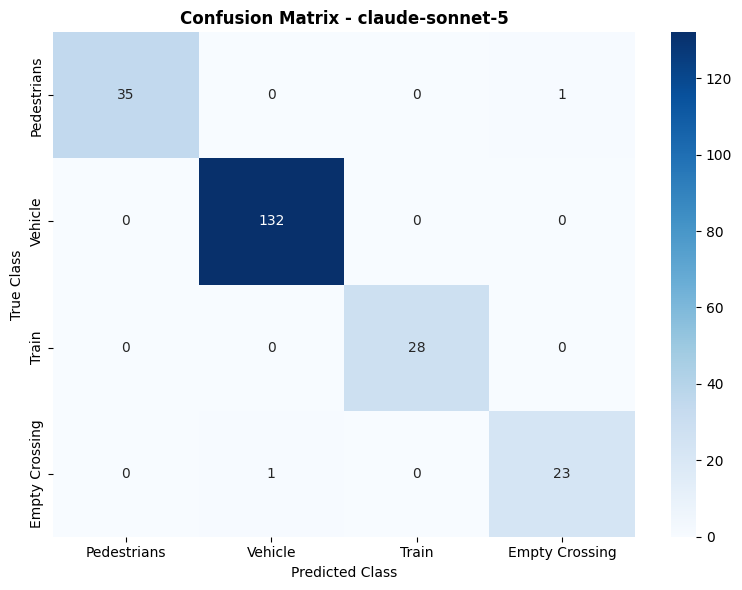

In [14]:
# ============================================================================
# 📊 CONFUSION MATRIX VISUALIZATION
# ============================================================================

if all_results:

    for model_name, metrics in model_metrics.items():

        if metrics is None:
            continue

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            metrics["confusion_matrix"],
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=metrics["classes"],
            yticklabels=metrics["classes"]
        )

        plt.title(
            f"Confusion Matrix - {model_name}",
            fontweight="bold"
        )

        plt.xlabel("Predicted Class")
        plt.ylabel("True Class")

        plt.tight_layout()
        plt.show()

else:
    print(
        "⚠️ No results available for visualization"
    )


In [15]:
# ============================================================================
# 🖼️ SEQUENTIAL IMAGE-BY-IMAGE PREDICTION REVIEW
# 220 Images → 5 Batches × 44 Images
# ============================================================================

import os
import math
import matplotlib.pyplot as plt
from PIL import Image


# ============================================================================
# SETTINGS
# ============================================================================

BATCH_SIZE = 44
NUM_BATCHES = 5

# Number of images per row
IMAGES_PER_ROW = 4


# ============================================================================
# VERIFY RESULTS
# ============================================================================

if "all_predictions" not in globals():

    print(
        "❌ all_predictions not found.\n"
        "Run the detailed prediction export/metrics cell first."
    )

else:

    # ------------------------------------------------------------------------
    # Select the model results
    # ------------------------------------------------------------------------
    model_names = all_predictions["Model"].unique()

    print("=" * 80)
    print("🖼️ SEQUENTIAL PREDICTION REVIEW")
    print("=" * 80)

    print(
        f"Models available: "
        f"{', '.join(model_names)}"
    )

    for model_name in model_names:

        print(
            f"\n🤖 Reviewing predictions for: "
            f"{model_name}"
        )

        # --------------------------------------------------------------------
        # Get current model results
        # --------------------------------------------------------------------
        model_df = (
            all_predictions[
                all_predictions["Model"] == model_name
            ]
            .copy()
            .reset_index(drop=True)
        )

        total_images = len(model_df)

        print(
            f"Total images available: "
            f"{total_images}"
        )

        # Safety check
        if total_images != 220:

            print(
                f"⚠️ Expected 220 images, "
                f"but found {total_images}."
            )

        # ====================================================================
        # CREATE 5 SEQUENTIAL BATCHES
        # ====================================================================

        for batch_num in range(NUM_BATCHES):

            start_idx = (
                batch_num * BATCH_SIZE
            )

            end_idx = min(
                start_idx + BATCH_SIZE,
                total_images
            )

            batch_df = model_df.iloc[
                start_idx:end_idx
            ]

            if len(batch_df) == 0:
                continue

            print("\n" + "=" * 80)

            print(
                f"📦 BATCH {batch_num + 1}/{NUM_BATCHES}"
            )

            print(
                f"Images {start_idx + 1}–{end_idx}"
            )

            print("=" * 80)

            # ----------------------------------------------------------------
            # Plot layout
            # ----------------------------------------------------------------
            n_images = len(batch_df)

            n_cols = IMAGES_PER_ROW

            n_rows = math.ceil(
                n_images / n_cols
            )

            fig, axes = plt.subplots(
                n_rows,
                n_cols,
                figsize=(
                    4 * n_cols,
                    3.6 * n_rows
                )
            )

            axes = axes.flatten()

            # ================================================================
            # DISPLAY EACH IMAGE
            # ================================================================

            for plot_idx, (_, row) in enumerate(
                batch_df.iterrows()
            ):

                ax = axes[plot_idx]

                img_path = row["Image_Path"]

                ground_truth = row[
                    "Ground_Truth"
                ]

                prediction = row[
                    "Prediction"
                ]

                correct = (
                    ground_truth
                    == prediction
                )

                try:

                    image = Image.open(
                        img_path
                    ).convert("RGB")

                    ax.imshow(image)

                except Exception as e:

                    ax.text(
                        0.5,
                        0.5,
                        "Image\nUnavailable",
                        ha="center",
                        va="center"
                    )

                ax.axis("off")

                # ------------------------------------------------------------
                # Image sequence number
                # ------------------------------------------------------------
                sequence_number = (
                    start_idx
                    + plot_idx
                    + 1
                )

                result_symbol = (
                    "✓"
                    if correct
                    else "✗"
                )

                # ------------------------------------------------------------
                # Title
                # ------------------------------------------------------------
                ax.set_title(
                    f"#{sequence_number} {result_symbol}\n"
                    f"True: {ground_truth}\n"
                    f"Pred: {prediction}",
                    fontsize=9,
                    fontweight="bold"
                )

            # ----------------------------------------------------------------
            # Hide unused subplot spaces
            # ----------------------------------------------------------------
            for empty_idx in range(
                n_images,
                len(axes)
            ):

                axes[
                    empty_idx
                ].axis("off")

            # ----------------------------------------------------------------
            # Main batch title
            # ----------------------------------------------------------------
            plt.suptitle(
                f"{model_name}\n"
                f"Batch {batch_num + 1}: "
                f"Images {start_idx + 1}–{end_idx}",
                fontsize=16,
                fontweight="bold",
                y=1.002
            )

            plt.tight_layout()

            plt.show()

    print(
        "\n✅ Sequential image review complete!"
    )


Output hidden; open in https://colab.research.google.com to view.


💰 API COST REPORT

🤖 claude-sonnet-5
--------------------------------------------------------------------------------
Images Processed:        220
Successful Predictions:  220/220 (100.0%)

💵 ESTIMATED API COST BREAKDOWN
  Total Input Tokens:    101,200
  Total Output Tokens:   33,000
  Total Tokens:          134,200
  Input Cost:            $0.2024
  Output Cost:           $0.3300
  ➜ TOTAL COST:          $0.5324
  Cost per Image:        $0.002420


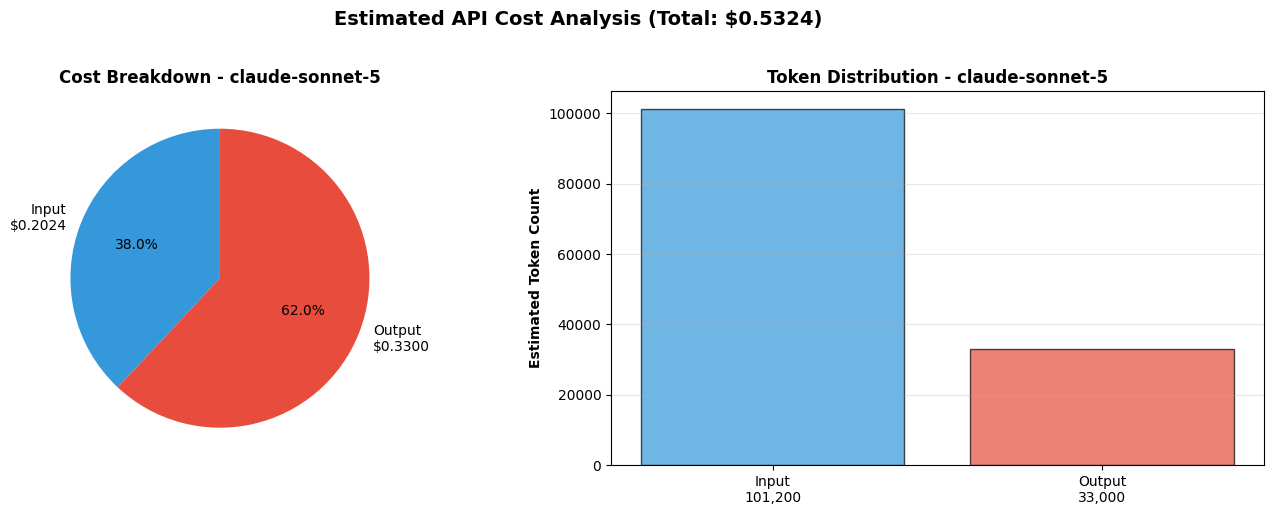


✅ API Cost Analysis Complete!


In [16]:
# ============================================================================
# 💰 API COST ANALYSIS
# ============================================================================

import matplotlib.pyplot as plt


# ============================================================================
# 1️⃣ MODEL PRICING
# ============================================================================

# ⚠️ Set these values according to the model being evaluated.
#
# CLAUDE NOTEBOOK:
# Use Claude Sonnet 5 pricing.
#

MODEL_PRICING = {
    "input_cost_per_1k": 0.002,
    "output_cost_per_1k": 0.010
}


# ============================================================================
# 2️⃣ API COST CALCULATION FUNCTION
# ============================================================================

def calculate_api_costs(
    results_df,
    num_images,
    avg_input_tokens=460,
    avg_output_tokens=150
):
    """
    Estimate total API usage cost.

    NOTE:
    Token counts are estimated unless actual API usage
    values are recorded during inference.
    """

    if num_images == 0:

        return {
            "num_images": 0,
            "total_input_tokens": 0,
            "total_output_tokens": 0,
            "total_tokens": 0,
            "input_cost": 0,
            "output_cost": 0,
            "total_cost": 0,
            "cost_per_image": 0
        }

    # ------------------------------------------------------------------------
    # Estimated Token Usage
    # ------------------------------------------------------------------------
    total_input_tokens = (
        num_images * avg_input_tokens
    )

    total_output_tokens = (
        num_images * avg_output_tokens
    )

    # ------------------------------------------------------------------------
    # Cost Calculation
    # ------------------------------------------------------------------------
    input_cost = (
        total_input_tokens / 1000
    ) * MODEL_PRICING["input_cost_per_1k"]

    output_cost = (
        total_output_tokens / 1000
    ) * MODEL_PRICING["output_cost_per_1k"]

    total_cost = (
        input_cost + output_cost
    )

    cost_per_image = (
        total_cost / num_images
    )

    return {

        "num_images":
            num_images,

        "total_input_tokens":
            total_input_tokens,

        "total_output_tokens":
            total_output_tokens,

        "total_tokens":
            total_input_tokens + total_output_tokens,

        "input_cost":
            input_cost,

        "output_cost":
            output_cost,

        "total_cost":
            total_cost,

        "cost_per_image":
            cost_per_image
    }


# ============================================================================
# 3️⃣ CALCULATE & PRINT API COST REPORT
# ============================================================================

if all_results:

    print("\n" + "=" * 80)
    print("💰 API COST REPORT")
    print("=" * 80)

    for model_name, results_df in all_results.items():

        num_images = len(results_df)

        num_successful = len(
            results_df[
                results_df["Prediction"] != "ERROR"
            ]
        )

        # --------------------------------------------------------------------
        # Calculate estimated API cost
        # --------------------------------------------------------------------
        cost_info = calculate_api_costs(
            results_df,
            num_images
        )

        print(f"\n🤖 {model_name}")
        print("-" * 80)

        print(
            f"Images Processed:        "
            f"{cost_info['num_images']}"
        )

        if num_images > 0:

            success_rate = (
                num_successful /
                num_images *
                100
            )

        else:
            success_rate = 0

        print(
            f"Successful Predictions:  "
            f"{num_successful}/{num_images} "
            f"({success_rate:.1f}%)"
        )

        print("\n💵 ESTIMATED API COST BREAKDOWN")

        print(
            f"  Total Input Tokens:    "
            f"{cost_info['total_input_tokens']:,}"
        )

        print(
            f"  Total Output Tokens:   "
            f"{cost_info['total_output_tokens']:,}"
        )

        print(
            f"  Total Tokens:          "
            f"{cost_info['total_tokens']:,}"
        )

        print(
            f"  Input Cost:            "
            f"${cost_info['input_cost']:.4f}"
        )

        print(
            f"  Output Cost:           "
            f"${cost_info['output_cost']:.4f}"
        )

        print(
            f"  ➜ TOTAL COST:          "
            f"${cost_info['total_cost']:.4f}"
        )

        print(
            f"  Cost per Image:        "
            f"${cost_info['cost_per_image']:.6f}"
        )

        # --------------------------------------------------------------------
        # Cost Visualization
        # --------------------------------------------------------------------
        fig, (ax1, ax2) = plt.subplots(
            1,
            2,
            figsize=(14, 5)
        )

        # Cost breakdown pie chart
        costs = [
            cost_info["input_cost"],
            cost_info["output_cost"]
        ]

        labels = [
            f"Input\n${cost_info['input_cost']:.4f}",
            f"Output\n${cost_info['output_cost']:.4f}"
        ]

        colors = [
            "#3498db",
            "#e74c3c"
        ]

        ax1.pie(
            costs,
            labels=labels,
            autopct="%1.1f%%",
            colors=colors,
            startangle=90
        )

        ax1.set_title(
            f"Cost Breakdown - {model_name}",
            fontweight="bold",
            fontsize=12
        )

        # --------------------------------------------------------------------
        # Token Breakdown
        # --------------------------------------------------------------------
        tokens = [
            cost_info["total_input_tokens"],
            cost_info["total_output_tokens"]
        ]

        token_labels = [
            f"Input\n{cost_info['total_input_tokens']:,}",
            f"Output\n{cost_info['total_output_tokens']:,}"
        ]

        ax2.bar(
            token_labels,
            tokens,
            color=colors,
            edgecolor="black",
            alpha=0.7
        )

        ax2.set_ylabel(
            "Estimated Token Count",
            fontweight="bold"
        )

        ax2.set_title(
            f"Token Distribution - {model_name}",
            fontweight="bold",
            fontsize=12
        )

        ax2.grid(
            axis="y",
            alpha=0.3
        )

        plt.suptitle(
            f"Estimated API Cost Analysis "
            f"(Total: ${cost_info['total_cost']:.4f})",
            fontsize=14,
            fontweight="bold",
            y=1.02
        )

        plt.tight_layout()
        plt.show()


    print("\n" + "=" * 80)
    print("✅ API Cost Analysis Complete!")
    print("=" * 80)